# 02 · Train — fine-tune 1D ResNet on PTB-XL superclasses

**Task:** multi-label classification into 5 diagnostic superclasses: NORM, MI, STTC, CD, HYP  
**Split:** folds 1–8 train · fold 9 val · fold 10 test (strat_fold column, never modified)  
**Output:** `checkpoints/best_model.pt`, `checkpoints/test_preds.npy`, `checkpoints/test_targets.npy`

Run all cells top to bottom. Training takes ~20–40 min on CPU, ~5 min with a GPU.

In [1]:
import sys
!{sys.executable} -m pip install wfdb scikit-learn tqdm --quiet

In [2]:
import ast, os, json
import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

DATA_DIR      = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
CKPT_DIR      = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

SAMPLING_RATE = 100          # 100 Hz → 1000 time-steps per record
SUPERCLASSES  = ["NORM", "MI", "STTC", "CD", "HYP"]
N_CLASSES     = len(SUPERCLASSES)
BATCH_SIZE    = 64
EPOCHS        = 30
LR            = 1e-3
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

/Users/roshani/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/roshani/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Device: cpu


## 1 · Load metadata and build label matrix

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"), index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

agg = pd.read_csv(os.path.join(DATA_DIR, "scp_statements.csv"), index_col=0)
agg = agg[agg["diagnostic"] == 1]

def aggregate_superclass(scp_dict):
    out = set()
    for code, lkl in scp_dict.items():
        if code in agg.index and lkl > 0:
            sc = agg.loc[code, "diagnostic_class"]
            if pd.notna(sc):
                out.add(sc)
    return list(out)

df["superclass"] = df["scp_codes"].apply(aggregate_superclass)

# Build binary label matrix — one row per record, one column per superclass
label_matrix = np.zeros((len(df), N_CLASSES), dtype=np.float32)
for i, sc_list in enumerate(df["superclass"]):
    for sc in sc_list:
        if sc in SUPERCLASSES:
            label_matrix[i, SUPERCLASSES.index(sc)] = 1.0

df["label_idx"] = range(len(df))  # position in label_matrix

train_df = df[df["strat_fold"] <= 8]
val_df   = df[df["strat_fold"] == 9]
test_df  = df[df["strat_fold"] == 10]
print(f"Train {len(train_df):,}  Val {len(val_df):,}  Test {len(test_df):,}")

Train 17,418  Val 2,183  Test 2,198


## 2 · Dataset and DataLoader

In [4]:
class ECGDataset(Dataset):
    """Returns one ECG as a (12, 1000) float32 tensor and its label vector."""

    def __init__(self, meta_df: pd.DataFrame, labels: np.ndarray, data_dir: str, sampling_rate: int = 100):
        self.meta      = meta_df.reset_index()
        self.labels    = labels
        self.data_dir  = data_dir
        self.fname_col = "filename_lr" if sampling_rate == 100 else "filename_hr"

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row  = self.meta.iloc[idx]
        path = os.path.join(self.data_dir, row[self.fname_col])
        sig, _ = wfdb.rdsamp(path)                        # (1000, 12)
        sig = sig.T.astype(np.float32)                    # (12, 1000)
        # z-score normalise each lead independently
        mu  = sig.mean(axis=1, keepdims=True)
        std = sig.std(axis=1, keepdims=True) + 1e-8
        sig = (sig - mu) / std
        label = self.labels[row["label_idx"]]
        return torch.from_numpy(sig), torch.from_numpy(label)


train_ds = ECGDataset(train_df, label_matrix, DATA_DIR, SAMPLING_RATE)
val_ds   = ECGDataset(val_df,   label_matrix, DATA_DIR, SAMPLING_RATE)
test_ds  = ECGDataset(test_df,  label_matrix, DATA_DIR, SAMPLING_RATE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Batches — train {len(train_loader)}  val {len(val_loader)}  test {len(test_loader)}")

Batches — train 273  val 35  test 35


## 3 · Model — 1D ResNet (resnet1d_wang architecture)

In [5]:
class ResBlock1d(nn.Module):
    """Basic residual block for 1-D signals.

    Uses odd kernel (default 15) so padding = kernel // 2 preserves length exactly.
    Even kernels (e.g. 16) grow the output by 1 per conv and break the residual add.
    """

    def __init__(self, in_ch: int, out_ch: int, kernel: int = 15, stride: int = 1, dropout: float = 0.2):
        super().__init__()
        pad = kernel // 2  # exact length preservation when kernel is odd
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, stride=1, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)

        self.downsample = None
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        identity = x if self.downsample is None else self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class ResNet1d(nn.Module):
    """1-D ResNet for 12-lead ECG classification (resnet1d_wang style)."""

    def __init__(self, in_channels: int = 12, num_classes: int = 5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.layer1 = ResBlock1d(64,  64,  stride=1)
        self.layer2 = ResBlock1d(64,  128, stride=2)
        self.layer3 = ResBlock1d(128, 256, stride=2)
        self.layer4 = ResBlock1d(256, 512, stride=2)
        self.pool   = nn.AdaptiveAvgPool1d(1)
        self.head   = nn.Linear(512, num_classes)

    def forward(self, x):            # x: (B, 12, 1000)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).squeeze(-1) # (B, 512)
        return self.head(x)          # (B, 5) logits


model = ResNet1d(in_channels=12, num_classes=N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

Parameters: 8,056,197


## 4 · Training loop

In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_auc = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_ds)

    # ── validate ───────────────────────────────────────────────────────────
    model.eval()
    val_preds, val_tgts = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb.to(DEVICE))
            val_preds.append(torch.sigmoid(logits).cpu().numpy())
            val_tgts.append(yb.numpy())
    val_preds = np.concatenate(val_preds)
    val_tgts  = np.concatenate(val_tgts)
    val_auc   = roc_auc_score(val_tgts, val_preds, average="macro")

    scheduler.step()

    print(f"Epoch {epoch:02d}  train_loss={train_loss:.4f}  val_macro_auc={val_auc:.4f}")
    history.append({"epoch": epoch, "train_loss": train_loss, "val_auc": val_auc})

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_model.pt"))
        print(f"  ✓ saved best model (val AUC {best_val_auc:.4f})")

pd.DataFrame(history).to_csv(os.path.join(CKPT_DIR, "training_history.csv"), index=False)
print(f"\nBest val macro AUC: {best_val_auc:.4f}")

Epoch 01  train_loss=0.3533  val_macro_auc=0.8783
  ✓ saved best model (val AUC 0.8783)


Epoch 02  train_loss=0.3096  val_macro_auc=0.8903
  ✓ saved best model (val AUC 0.8903)


Epoch 03  train_loss=0.2945  val_macro_auc=0.8954
  ✓ saved best model (val AUC 0.8954)


Epoch 04  train_loss=0.2838  val_macro_auc=0.8948


Epoch 05  train_loss=0.2757  val_macro_auc=0.8978
  ✓ saved best model (val AUC 0.8978)


...

Epoch 26  train_loss=0.0498  val_macro_auc=0.8861


Epoch 27  train_loss=0.0440  val_macro_auc=0.8865


Epoch 28  train_loss=0.0401  val_macro_auc=0.8878


Epoch 29  train_loss=0.0384  val_macro_auc=0.8867


Epoch 30  train_loss=0.0368  val_macro_auc=0.8871

Best val macro AUC: 0.9071


## 5 · Run inference on fold 10 and save predictions

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load(os.path.join(CKPT_DIR, "best_model.pt"), map_location=DEVICE))
model.eval()

test_preds, test_tgts = [], []
with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Test inference"):
        logits = model(xb.to(DEVICE))
        test_preds.append(torch.sigmoid(logits).cpu().numpy())
        test_tgts.append(yb.numpy())

test_preds = np.concatenate(test_preds)   # (N_test, 5) sigmoid outputs
test_tgts  = np.concatenate(test_tgts)    # (N_test, 5) binary targets

np.save(os.path.join(CKPT_DIR, "test_preds.npy"),   test_preds)
np.save(os.path.join(CKPT_DIR, "test_targets.npy"), test_tgts)

test_macro_auc = roc_auc_score(test_tgts, test_preds, average="macro")
print(f"Test macro AUC (fold 10): {test_macro_auc:.4f}")
print(f"Predictions saved to {CKPT_DIR}/")

Test inference: 100%|██████████| 35/35 [13:45<00:00, 23.60s/it]  

Test macro AUC (fold 10): 0.9038
Predictions saved to checkpoints/


## 6 · Training curve

Quick sanity check — loss should decrease, val AUC should rise and plateau.

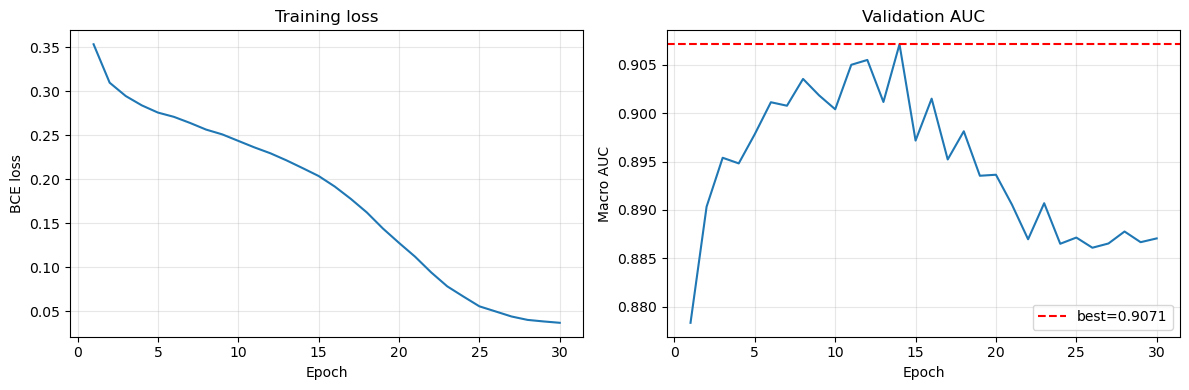

Saved training_curve.png


In [8]:
import matplotlib.pyplot as plt

# Load from disk so this cell works even after a kernel restart
hist = pd.read_csv(os.path.join(CKPT_DIR, "training_history.csv"))
best_val_auc = hist["val_auc"].max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist["epoch"], hist["train_loss"])
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE loss"); ax1.set_title("Training loss")
ax1.grid(True, alpha=0.3)

ax2.plot(hist["epoch"], hist["val_auc"])
ax2.axhline(best_val_auc, color="red", linestyle="--", label=f"best={best_val_auc:.4f}")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Macro AUC"); ax2.set_title("Validation AUC")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "training_curve.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved training_curve.png")

---
**Next:** open `03_evaluate.ipynb` and run all cells.  
It will load `checkpoints/test_preds.npy` and produce the full evaluation table.